In [9]:
# import necessary libraries

import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sklearn.metrics 
import math
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb # extreme gradient boosting 
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, cohen_kappa_score, confusion_matrix, roc_auc_score, roc_curve
import pickle #to save and load the model
import os 

import warnings
warnings.filterwarnings("ignore") # Filter out all warnings

## About Data:
* ###### label: This is a binary variable that indicates whether a location is prone to flooding or not. it stand for Flood/No Flood.

* ###### Aspect: This is the direction in which a slope faces. The aspect can affect the amount of solar radiation a slope receives, which can influence evaporation and snowmelt rates.

* ###### elevation: Digital Elevation Model. It represents the elevation of a location relative to sea level. Elevation can affect the likelihood and severity of flooding, as low-lying areas are more susceptible to flooding than higher elevations.

* ###### Distance from river: This feature represents the distance between a location and a river. Locations closer to a river may be more prone to flooding, especially during periods of heavy rainfall or snowmelt.


* ###### Land use: This is the type of land cover at a location. Land use can affect the amount and rate of water infiltration into the soil, which can influence runoff rates and flooding potential.

* ###### Plan curvature: This is a measure of how a slope curves in a two-dimensional plane. Plan curvature can influence the direction and speed of water flow over the surface.

* ###### Profile curvature: This is a measure of how a slope curves in a three-dimensional space. Profile curvature can influence the amount and speed of water flow over the surface.

* ###### Rainfall: This is the amount of precipitation that falls at a location. Heavy rainfall can increase the likelihood and severity of flooding.

* ###### Slope: This is the steepness of a slope. Steeper slopes can lead to higher runoff rates and increased flood potential.

* ###### Soil: This is the type of soil at a location. Soil type can affect the infiltration rate and water-holding capacity of the ground, which can influence the potential for flooding.

* ###### SPI: Standardized Precipitation Index (SPI) is a measure of precipitation deficits or surpluses over a specific time period relative to the long-term average. SPI values are standardized to a normal distribution, making it easier to compare different regions and time periods. SPI values can indicate the severity and duration of drought or excess rainfall events, which can contribute to flooding.

* ###### TWI: Terrain Wetness Index (TWI) is a measure of soil moisture content and its effect on the potential for flooding. TWI values are calculated using topographic and soil data, and they indicate areas with a high potential for saturation and surface runoff. TWI is especially useful in predicting flash floods, where heavy precipitation falls on already saturated soil.

* ###### Population density is a key demographic indicator that helps understand the distribution of the population in a given region.It refers to the number of people living per unit area, usually per square kilometer or square mile. 

* ###### Drainage Density: This measures the amount of channels or watercourses in a given area. High drainage density indicates a well-developed network of channels, potentially affecting water flow and flood risk.

* ###### Distance to Road: The proximity to roads can impact water runoff and drainage. Roads can alter natural drainage patterns, and their presence may affect how water is directed and channeled across the landscape.

In [10]:
# set environment 
directory = 'flood-suscep/'
os.makedirs(directory, exist_ok=True)

In [11]:
### Select 185 random points as non-flood locations 
# rand= gpd.read_file(r'conccat_raster_nonflood/Export_Output.shp')
# rand.head()

# # Randomly select 185 points
# random_selection = rand.sample(n=185, random_state=42)  # Adjust 'random_state' for reproducibility

# # Display the selected points
# print(random_selection.shape)
# random_selection.head()

In [12]:
# Read the flooded point data
flood_data=gpd.read_file("datasets/points/flood_utm.shp")
flood_data.rename(columns={'Id': 'label'}, inplace=True)
print(flood_data.shape)
flood_data.head()

(185, 16)


,label,elevation,aspect,slope,plan_curva,prof_curva,drainage_d,dist_river,dist_road,landuse,rainfall,population,TWI,SPI,soil,geometry
0,1,20,210.9640,4.16874,0.244444,0.022222,0.211917,1124.500,169.706,7,1520.80,23793.40,6.00643,0.00000,11,POINT (542632.001 729674.241)
1,1,7,93.8141,3.58425,-0.222222,0.111111,0.493057,283.019,1979.090,7,1543.22,18602.20,7.25436,3.66047,0,POINT (542644.073 721168.759)
2,1,-1,233.1300,4.76364,0.281609,0.726054,0.828435,429.535,582.495,4,1533.90,2886.91,6.97280,4.86957,0,POINT (552335.359 732321.398)
3,1,4,291.0380,3.32143,0.213675,0.102564,0.943900,600.000,797.120,7,1545.13,6622.36,6.23084,0.00000,11,POINT (553842.320 729766.968)
4,1,6,225.0000,2.02487,0.166667,-0.055556,1.923570,390.000,2438.130,7,1561.52,2567.51,6.71563,0.00000,11,POINT (536115.279 709356.734)


In [13]:
# Read the nonflooded point data
nonflood_data=gpd.read_file("datasets/points/nonflood2_utm.shp")
# # rename nonflood data 'ID' with 'label'
nonflood_data = nonflood_data.rename(columns={'grid_code': 'label'})
print(nonflood_data.shape)
nonflood_data.head()

(185, 16)


,label,elevation,aspect,slope,plan_curva,prof_curva,drainage_d,dist_river,dist_road,landuse,rainfall,population,TWI,SPI,soil,geometry
0,0,9,54.4623,2.052780,0.022222,-0.088889,0.000000,1413.82,483.735,7,1574.56,6390.100,6.70230,0.000,0,POINT (546041.824 710353.554)
1,0,17,315.0000,0.675206,0.111111,-0.111111,0.000000,1336.60,2431.300,2,1485.36,974.071,7.76069,0.000,0,POINT (517241.824 720373.554)
2,0,36,246.8010,3.631390,0.078431,-0.477124,0.000000,1425.24,3160.840,7,1494.41,8971.340,6.14285,0.000,11,POINT (526151.824 737803.554)
3,0,17,63.4349,3.199600,0.290598,-0.042735,0.015500,1159.18,8580.730,2,1715.76,223.823,6.26764,0.000,0,POINT (606311.824 713923.554)
4,0,13,186.3400,2.160790,-0.000000,0.000000,0.170831,1039.66,1418.910,7,1467.04,2550.150,12.14950,267.907,0,POINT (512411.824 719893.554)


In [14]:
#concat the flood and nonflood points
points=pd.concat([flood_data,nonflood_data], ignore_index=True)
print(points.shape)
points.head()

(370, 16)


,label,elevation,aspect,slope,plan_curva,prof_curva,drainage_d,dist_river,dist_road,landuse,rainfall,population,TWI,SPI,soil,geometry
0,1,20,210.9640,4.16874,0.244444,0.022222,0.211917,1124.500,169.706,7,1520.80,23793.40,6.00643,0.00000,11,POINT (542632.001 729674.241)
1,1,7,93.8141,3.58425,-0.222222,0.111111,0.493057,283.019,1979.090,7,1543.22,18602.20,7.25436,3.66047,0,POINT (542644.073 721168.759)
2,1,-1,233.1300,4.76364,0.281609,0.726054,0.828435,429.535,582.495,4,1533.90,2886.91,6.97280,4.86957,0,POINT (552335.359 732321.398)
3,1,4,291.0380,3.32143,0.213675,0.102564,0.943900,600.000,797.120,7,1545.13,6622.36,6.23084,0.00000,11,POINT (553842.320 729766.968)
4,1,6,225.0000,2.02487,0.166667,-0.055556,1.923570,390.000,2438.130,7,1561.52,2567.51,6.71563,0.00000,11,POINT (536115.279 709356.734)


In [15]:
# # Save the concat GeoDataFrame to a shapefile
# points.to_file(os.path.join(directory, r"datasets\points\all_fdpoints.shp"))

In [16]:
# read the dataframe containing the features 
gdf= gpd.read_file(r"datasets\points\all_fdpoints.shp")
# Move the 'label' column to the end
gdf = gdf[[col for col in gdf.columns if col != 'label'] + ['label']]

#check the data dimensions
print(gdf.shape)
gdf.head()

(370, 16)


,elevation,aspect,slope,plan_curva,prof_curva,drainage_d,dist_river,dist_road,landuse,rainfall,population,TWI,SPI,soil,geometry,label
0,20,210.9640,4.16874,0.244444,0.022222,0.211917,1124.500,169.706,7,1520.80,23793.40,6.00643,0.00000,11,POINT (542632.001 729674.241),1
1,7,93.8141,3.58425,-0.222222,0.111111,0.493057,283.019,1979.090,7,1543.22,18602.20,7.25436,3.66047,0,POINT (542644.073 721168.759),1
2,-1,233.1300,4.76364,0.281609,0.726054,0.828435,429.535,582.495,4,1533.90,2886.91,6.97280,4.86957,0,POINT (552335.359 732321.398),1
3,4,291.0380,3.32143,0.213675,0.102564,0.943900,600.000,797.120,7,1545.13,6622.36,6.23084,0.00000,11,POINT (553842.320 729766.968),1
4,6,225.0000,2.02487,0.166667,-0.055556,1.923570,390.000,2438.130,7,1561.52,2567.51,6.71563,0.00000,11,POINT (536115.279 709356.734),1


In [17]:
# check the info
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   elevation   370 non-null    int64   
 1   aspect      370 non-null    float64 
 2   slope       370 non-null    float64 
 3   plan_curva  370 non-null    float64 
 4   prof_curva  370 non-null    float64 
 5   drainage_d  370 non-null    float64 
 6   dist_river  370 non-null    float64 
 7   dist_road   370 non-null    float64 
 8   landuse     370 non-null    int64   
 9   rainfall    370 non-null    float64 
 10  population  370 non-null    float64 
 11  TWI         370 non-null    float64 
 12  SPI         370 non-null    float64 
 13  soil        370 non-null    int64   
 14  geometry    370 non-null    geometry
 15  label       370 non-null    int64   
dtypes: float64(11), geometry(1), int64(4)
memory usage: 46.4 KB


In [18]:
#get the summary statistics of the datafrmae
gdf.describe().T

,count,mean,std,min,25%,50%,75%,max
elevation,370.0,14.829730,13.498196,-1.00000,5.250000,10.000000,20.000000,71.000000
aspect,370.0,175.039830,106.203657,-1.00000,79.769400,180.000000,270.000000,353.660000
slope,370.0,2.886070,1.991900,0.00000,1.554048,2.409540,3.584250,14.780800
plan_curva,370.0,-0.000321,0.190772,-1.06667,-0.111111,0.000000,0.111111,0.604444
prof_curva,370.0,0.019199,0.209722,-1.10997,-0.110731,0.000000,0.111111,1.266670
drainage_d,370.0,0.604743,0.882153,0.00000,0.000000,0.139316,0.949180,4.326590
dist_river,370.0,982.923587,531.518171,0.00000,569.407500,1070.790000,1321.105000,3390.130000
dist_road,370.0,3582.249467,6061.078700,0.00000,510.879250,1414.455000,3743.625000,35408.700000
landuse,370.0,5.494595,2.473978,1.00000,2.000000,7.000000,7.000000,11.000000
rainfall,370.0,1574.021784,97.483123,1379.56000,1510.692500,1552.005000,1662.647500,1816.250000


<Axes: xlabel='label', ylabel='count'>

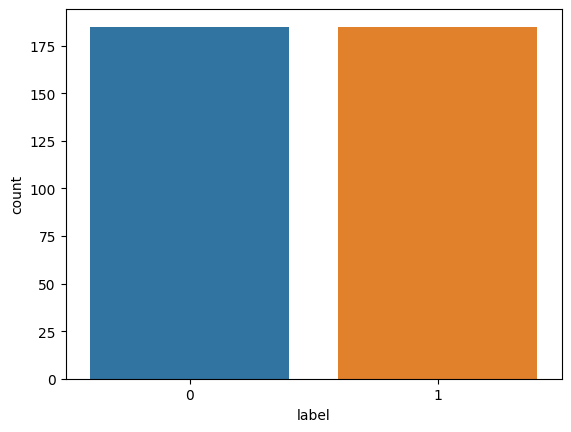

In [19]:
#Understand the data 
# The dataset includes the same number of flooded and not flooded locations
sns.countplot(x="label", data=gdf) #0 - Notflooded   1 - Flooded

In [20]:

# Define mapping for soil values
soil_mapping = {
    11: 'Fluvisols',
    0: 'Acrisols',
    6: 'Cambisols',
    12: 'Gleysols',
    29: 'Vertisols',
    4: 'Arenosols',
    17: 'Lixisols',
    18: 'Luvisols'
}

# Define mapping for landuse values
landuse_mapping = {
    7: 'Rangeland',
    2: 'Built Area',
    1: 'Bare Ground',
    11: 'Wetland',
    8: 'Trees',
    5: 'Flooded Vegetation',
    4: 'Crops'
}


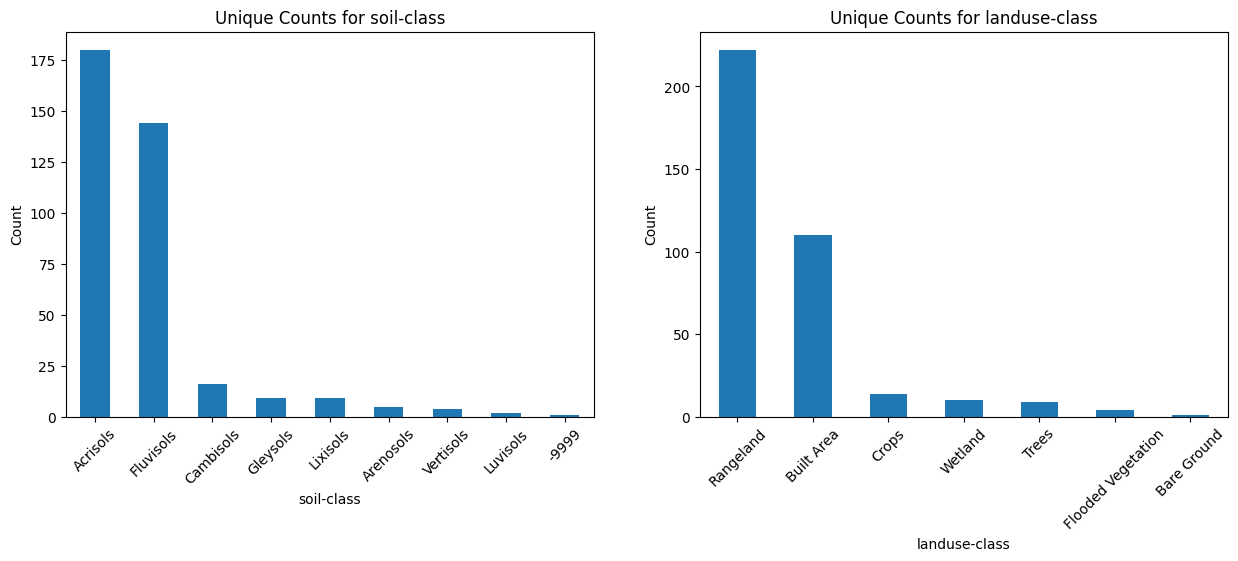

In [21]:
# Replace values in 'soil' and 'landuse' columns
gdf['soil-class'] = gdf['soil'].replace(soil_mapping)
gdf['landuse-class'] = gdf['landuse'].replace(landuse_mapping)

# Count of unique values for categorical columns
categorical_columns = ['soil-class', 'landuse-class']
for col in categorical_columns:
    unique_counts = gdf[col].value_counts()
    # print(f"Unique counts for {col}:\n{unique_counts}\n")

# Create a figure with subplots for each categorical column
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))

for idx, col in enumerate(categorical_columns):
    unique_counts = gdf[col].value_counts()
    unique_counts.plot(kind='bar', ax=axes[idx], title=f'Unique Counts for {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

# plt.tight_layout()
plt.show()

#### Feature Selection

Information gain ratio

In [22]:
def information_gain_ratio(data, attribute):
    # Calculate the entropy of the original dataset
    entropy_original = calculate_entropy(data, 'label')  # Assuming the target column is 'label'

    # Calculate the entropy of each child dataset
    entropies = []
    for value in data[attribute].unique():
        child_data = data[data[attribute] == value]
        entropy = calculate_entropy(child_data, 'label')  # Assuming the target column is 'label'
        entropies.append(entropy * (len(child_data) / len(data)))

    # Calculate the split entropy
    split_entropy = sum(entropies)

    # Calculate the information gain
    information_gain = entropy_original - split_entropy

    # Calculate the split information
    split_information = calculate_entropy(data, attribute)

    # Calculate the information gain ratio
    information_gain_ratio = information_gain / split_information
    return information_gain_ratio


def calculate_entropy(data, target_column):
    entropy = 0
    probabilities = data[target_column].value_counts() / len(data)
    for probability in probabilities:
        if probability > 0:
            entropy -= probability * math.log2(probability)
    return entropy

In [23]:
# Get the mutual score of each features
attributes = ['elevation', 'aspect', 'slope', 'plan_curva', 'prof_curva', 'drainage_d', 'dist_river', 'dist_road', 'landuse', 'rainfall', 'population', 'TWI', 'SPI', 'soil']

information_gains = []
for attribute_name in attributes:
    result = information_gain_ratio(gdf, attribute_name)
    information_gains.append(result)
    print(f"Information Gain Ratio for {attribute_name}: {result}")


Information Gain Ratio for elevation: 0.05257730297312798
Information Gain Ratio for aspect: 0.07005865578346118
Information Gain Ratio for slope: 0.05724462973497569
Information Gain Ratio for plan_curva: 0.0652319866154452
Information Gain Ratio for prof_curva: 0.06961006665315086
Information Gain Ratio for drainage_d: 0.12682520511385265
Information Gain Ratio for dist_river: 0.11283646174598953
Information Gain Ratio for dist_road: 0.11025327791674695
Information Gain Ratio for landuse: 0.13106570673546708
Information Gain Ratio for rainfall: 0.11665463146572891
Information Gain Ratio for population: 0.11783540340231809
Information Gain Ratio for TWI: 0.09417016347851163
Information Gain Ratio for SPI: 0.09766832470445756
Information Gain Ratio for soil: 0.10604242254076372


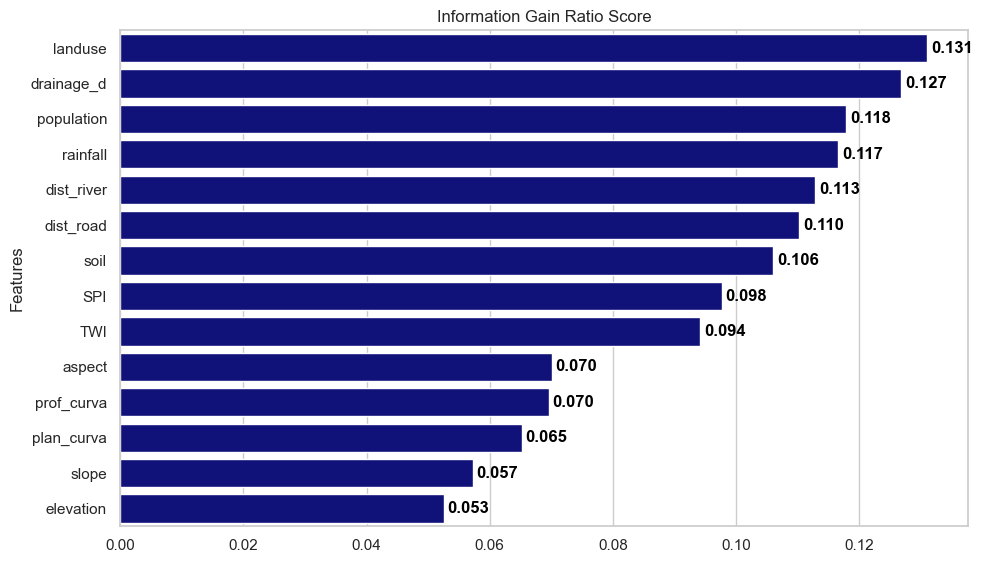

In [24]:
# Create a DataFrame with attributes and information gains
igr_df = pd.DataFrame({'Features': attributes, 'InformationGainRatio': information_gains})
igr_df.rename(columns={'plan_curva': 'plan_curvature', 'prof_curva':'profile_curvature',
       'drainage_d': 'drainage_density', 'dist_river':'distance_river', 'dist_road': 'distance_road'}, inplace=True) 

# Sort the DataFrame in descending order by Information Gain Ratio
igr_df = igr_df.sort_values(by='InformationGainRatio', ascending=False)


# Set Seaborn style
sns.set(style="whitegrid")

# Plotting with Seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='InformationGainRatio', y='Features', data=igr_df, color='darkblue', ax=ax)

ax.set_xlabel(' ')
ax.set_ylabel('Features')
ax.set_title('Information Gain Ratio Score')

# Display values on the bars in bold
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}', (p.get_width()+ 0.004, p.get_y() + p.get_height() / 2),
                ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

#### Multicolonierity

In [25]:
# Define function for the VIF and TOL
def calculate_vif(X):
    """Calculates the variance inflation factor (VIF) for all independent variables in a NumPy array X."""
    vif = []
    corr_matrix = np.corrcoef(X.T)
    for i in range(X.shape[1]):
        diag = np.diag(corr_matrix)
        subdiag = corr_matrix[i, i+1:]
        vif.append(1 / (1 - np.sum(subdiag**2) / diag[i]))
    return vif

def calculate_tolerance(X):
    """Calculates the tolerance for all independent variables in a NumPy array X."""
    tolerance = []
    corr_matrix = np.corrcoef(X.T)
    for i in range(X.shape[1]):
        diag = np.diag(corr_matrix)
        subdiag = corr_matrix[i, i+1:]
        tolerance.append(1 - np.sum(subdiag**2) / diag[i])
    return tolerance

VIF and tolerance scores:
      variable       VIF  tolerance
5   drainage_d  9.679625   0.103310
6   dist_river  6.452764   0.154972
7    dist_road  2.101843   0.475773
3   plan_curva  1.876985   0.532769
0    elevation  1.801810   0.554998
8      landuse  1.744251   0.573312
2        slope  1.261770   0.792537
9     rainfall  1.162278   0.860379
11         TWI  1.128088   0.886456
10  population  1.126337   0.887834
4   prof_curva  1.098731   0.910141
1       aspect  1.080917   0.925141
12         SPI  1.005759   0.994274
13        soil  1.003245   0.996766
14       label  1.000000   1.000000


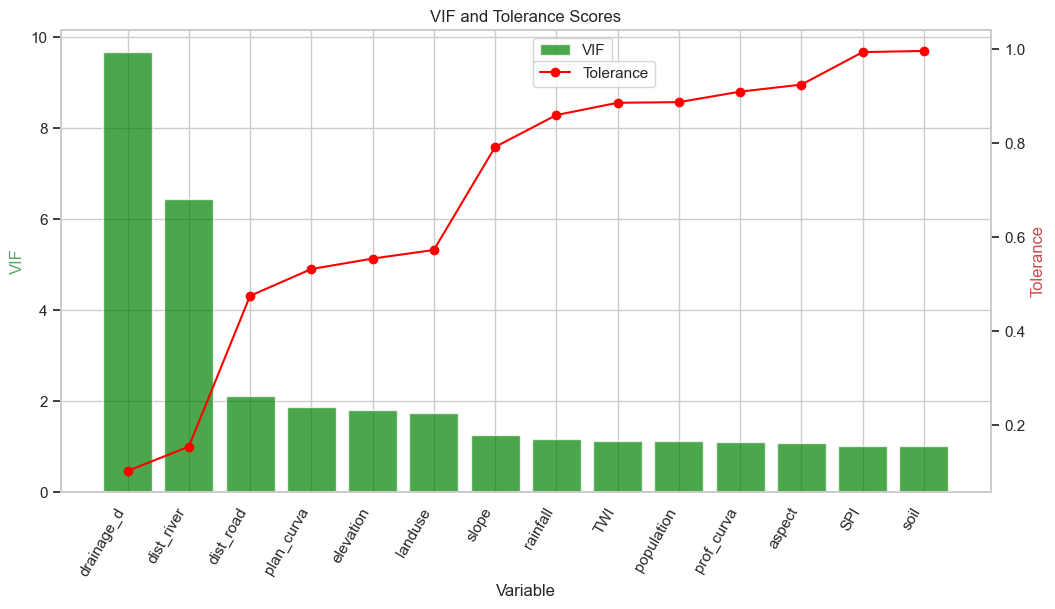

In [26]:
# Drop the columns not needed in the analysis
columns_to_exclude = [ 'geometry', 'soil-class', 'landuse-class']
X = gdf.drop(columns_to_exclude, axis=1).values

# Calculate the VIF and tolerance for the independent variables
vif = calculate_vif(X)
tolerance = calculate_tolerance(X)

# Create DataFrames for VIF and tolerance scores
vif_df = pd.DataFrame({'variable': gdf.drop(columns_to_exclude, axis=1).columns, 'VIF': vif})
tolerance_df = pd.DataFrame({'variable': gdf.drop(columns_to_exclude, axis=1).columns, 'tolerance': tolerance})

# Combine the VIF and tolerance DataFrames into a single DataFrame using an inner join
col_df = vif_df.merge(tolerance_df, on='variable', how='inner')
col_df = col_df.sort_values(by='VIF', ascending=False)


# Print the  DataFrame
print("VIF and tolerance scores:")
print(col_df[['variable', 'VIF', 'tolerance']])


#### Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))
# Rotating x-axis labels for better readability
plt.xticks(rotation=60, ha='right')

# Drop the target column
# combined_df_sorted = combined_df_sorted[combined_df_sorted['variable']!= 'slope']
col_df = col_df[col_df['variable']!=  'label']
ax1.bar(col_df['variable'], col_df['VIF'], color='green', alpha=0.7, label='VIF')

# Creating a second y-axis for tolerance
ax2 = ax1.twinx()
ax2.plot(col_df['variable'], col_df['tolerance'], color='red', marker='o', label='Tolerance')

# Setting labels and title
ax1.set_xlabel('Variable')
ax1.set_ylabel('VIF', color='g')
ax2.set_ylabel('Tolerance', color='r')
plt.title('VIF and Tolerance Scores')

# Adding legends at upper center
ax1.legend(loc='upper left', bbox_to_anchor=(0.5, 1.0))
ax2.legend(loc='upper left', bbox_to_anchor=(0.5, 0.95))

# Remove a horizontal gridline
ax2.yaxis.grid(which='major', color='gray', linestyle=' ', linewidth=0.5)
# 'which' can be 'major', 'minor', or 'both'

# Show the plot
plt.show()

Pearson correlation

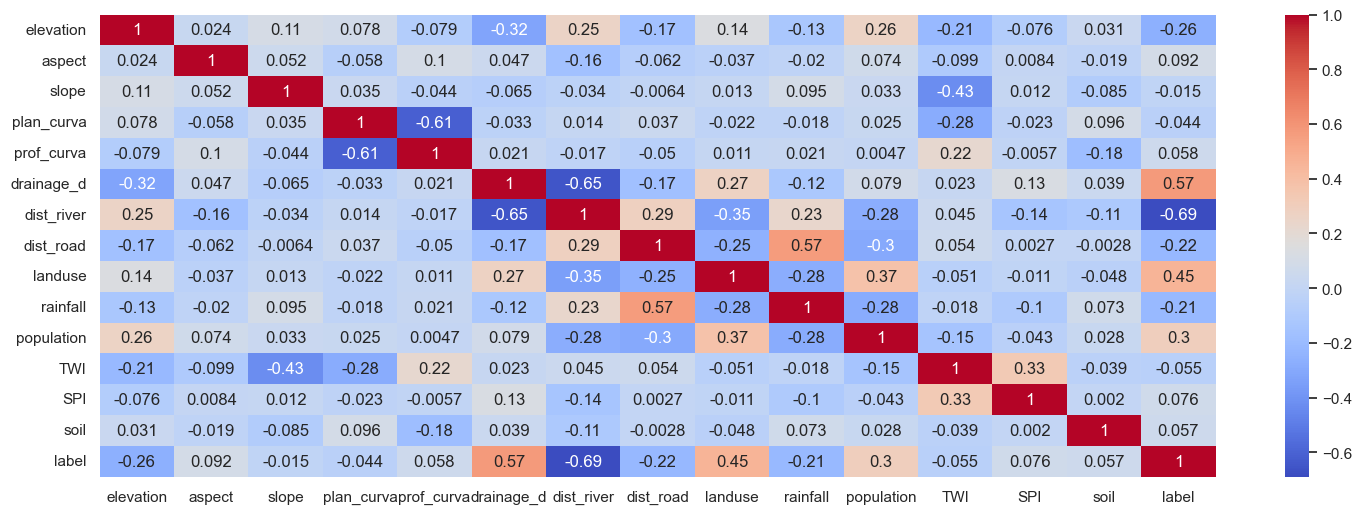

In [27]:
# Calculate the correlation coefficients
plt.figure(figsize=(18, 6))
correlation_matrix = gdf.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [28]:
gdf.dtypes 

elevation           int64
aspect            float64
slope             float64
plan_curva        float64
prof_curva        float64
drainage_d        float64
dist_river        float64
dist_road         float64
landuse             int64
rainfall          float64
population        float64
TWI               float64
SPI               float64
soil                int64
geometry         geometry
label               int64
soil-class         object
landuse-class      object
dtype: object

In [29]:
# drop the columns not needed in the analysis
gdf.drop(columns=[ 'soil-class', 'landuse-class'], inplace=True)

#### Data Nomilization and spliting 

In [30]:
#Extract the columns to be excluded from normalization
columns_to_exclude = ['label', 'soil', 'landuse', 'geometry']

# Separate the columns to be normalized
columns_to_normalize = [col for col in gdf.columns if col not in columns_to_exclude]

# Initialize the scaler
scaler = MinMaxScaler()

# Normalize only the selected columns
normalized_data = scaler.fit_transform(gdf[columns_to_normalize])
gdf_normalized = gdf.copy()  # Make a copy of the original DataFrame
gdf_normalized[columns_to_normalize] = normalized_data

# Split the dataset into a training set (80%) and a test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    gdf_normalized.drop(columns=['label','geometry' ]),  # Features (independent variables)
    gdf_normalized['label'],  # Target variable (dependent variable)
    test_size=0.3,
    shuffle=True,
    stratify=gdf_normalized['label'],
    random_state=42
)

In [31]:
# # Export the train and test datasets
# # Create a new column to indicate whether each row is in the training or test set
# gdf['set_type'] = 'training'
# gdf.loc[X_test.index, 'set_type'] = 'test'

# # Save the GeoDataFrame to a shapefile
# gdf.to_file(os.path.join(directory, r"datasets\flood_inventory.shp"))

In [32]:
(len(X_train)), (len(y_train)), (len(X_test)), (len(y_test))

(259, 259, 111, 111)

In [33]:
print(X_train.head())
print(y_train.head())

     elevation    aspect     slope  plan_curva  prof_curva  drainage_d  \
152   0.097222  0.256584  0.225865    0.638299    0.560536    0.316603   
14    0.055556  0.435445  0.144397    0.718086    0.476384    0.213704   
26    0.055556  0.890994  0.114175    0.625001    0.504434    0.295406   
99    0.180556  0.712133  0.102128    0.638299    0.467033    0.034257   
157   0.152778  0.839015  0.072223    0.638299    0.420282    0.690313   

     dist_river  dist_road  landuse  rainfall  population       TWI       SPI  \
152    0.309723   0.004793        7  0.446404    0.121023  0.168229  0.000026   
14     0.025029   0.066954       11  0.084385    0.096552  0.147161  0.000000   
26     0.081586   0.026155        7  0.333623    0.172502  0.532702  0.001106   
99     0.312867   0.210800        2  0.744739    0.089679  0.232310  0.000012   
157    0.281650   0.005684        7  0.419932    0.187379  0.202386  0.000000   

     soil  
152     0  
14      0  
26     11  
99      0  
157     

### Model and Evaluation

Random Forest

In [34]:
# train the model on train set 
RF = RandomForestClassifier() 
RF.fit(X_train, y_train) 
  
# print prediction results 
predictions = RF.predict(X_test) 
print(classification_report(y_test, predictions)) 

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        56
           1       0.96      0.87      0.91        55

    accuracy                           0.92       111
   macro avg       0.92      0.92      0.92       111
weighted avg       0.92      0.92      0.92       111



In [35]:
### Random forest parameter tuning 
param_grid = {'n_estimators':np.arange(10,200,20),
              'max_depth':np.arange(1,20,1) 
            #   'min_samples_leaf': np.arange(1, 10, 1)
            }
rfclassifier = RandomForestClassifier(random_state=11)
RF_model = GridSearchCV(rfclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
RF_model.fit(X_train, y_train)

Fitting 10 folds for each of 190 candidates, totalling 1900 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=11),
             n_jobs=-1,
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'n_estimators': array([ 10,  30,  50,  70,  90, 110, 130, 150, 170, 190])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [36]:
RF_model.best_params_

{'max_depth': 6, 'n_estimators': 70}

Accuracy for test dataset: 0.9009009009009009
Sensitivity for test dataset: 0.8727272727272727
Specificity for test dataset: 0.9285714285714286
Kappa score for test dataset: 0.8016891343186616



classification report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        56
           1       0.92      0.87      0.90        55

    accuracy                           0.90       111
   macro avg       0.90      0.90      0.90       111
weighted avg       0.90      0.90      0.90       111



Text(0.5, 1.0, 'Confusion Matrix of RF model')

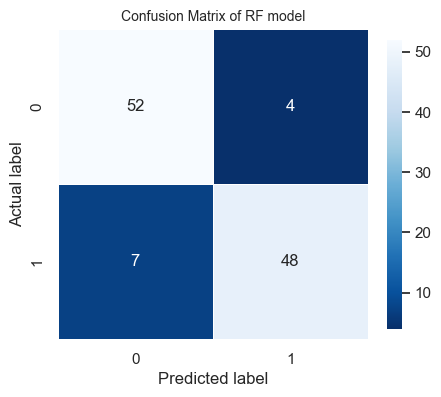

In [37]:
## Evaluate the model on best parameters
ytest_RF_predict = RF_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, ytest_RF_predict))
print("Sensitivity for test dataset:", recall_score(y_test,ytest_RF_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, ytest_RF_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, ytest_RF_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, ytest_RF_predict))
CM_RF = sklearn.metrics.confusion_matrix(y_test, ytest_RF_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_RF, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Confusion Matrix of RF model'
plt.title(title, size = 10)

AdaBoost

In [38]:
# train the model on train set 
ADB = AdaBoostClassifier() 
ADB.fit(X_train, y_train) 
  
# print prediction results 
y_ADB_pred = ADB.predict(X_test) 
print(classification_report(y_test, y_ADB_pred)) 

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        56
           1       0.87      0.85      0.86        55

    accuracy                           0.86       111
   macro avg       0.87      0.86      0.86       111
weighted avg       0.86      0.86      0.86       111



In [39]:
### Adaboost parameter tuning 
param_grid = {'n_estimators':np.arange(10,220,10), 
              'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]}
abclassifier = AdaBoostClassifier(random_state=11)
ADB_model = GridSearchCV(abclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
ADB_model.fit(X_train, y_train)

Fitting 10 folds for each of 336 candidates, totalling 3360 fits


GridSearchCV(cv=10, estimator=AdaBoostClassifier(random_state=11), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007,
                                           0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4,
                                           0.5, 0.6, 0.8, 1],
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [40]:
ADB_model.best_params_

{'learning_rate': 0.5, 'n_estimators': 70}

Accuracy for test dataset: 0.8918918918918919
Sensitivity for test dataset: 0.9090909090909091
Specificity for test dataset: 0.875
Kappa score for test dataset: 0.7838364167478091



classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        56
           1       0.88      0.91      0.89        55

    accuracy                           0.89       111
   macro avg       0.89      0.89      0.89       111
weighted avg       0.89      0.89      0.89       111



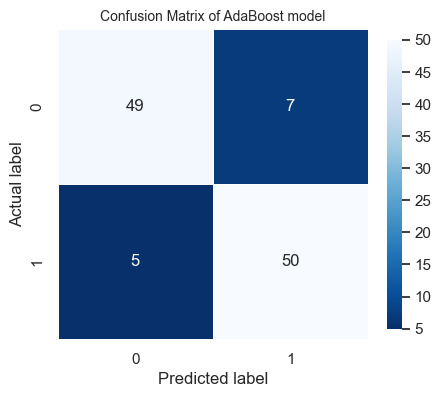

In [41]:
ytest_ADB_predict = ADB_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, ytest_ADB_predict))
print("Sensitivity for test dataset:", recall_score(y_test,ytest_ADB_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, ytest_ADB_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, ytest_ADB_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, ytest_ADB_predict))
CM_ADB = sklearn.metrics.confusion_matrix(y_test, ytest_ADB_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_ADB, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix of AdaBoost model'
plt.title(all_sample_title, size = 10);

K-Nearest Neigbour

In [42]:
# train the model on train set 
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train) 
  
# print prediction results 
kNN_pred = KNN.predict(X_test) 
print(classification_report(y_test, kNN_pred)) 

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        56
           1       0.84      0.84      0.84        55

    accuracy                           0.84       111
   macro avg       0.84      0.84      0.84       111
weighted avg       0.84      0.84      0.84       111



In [43]:
### KNN parameter tuning
param_grid = {
    'n_neighbors': np.arange(1, 100, 1),  # Adjust the range of neighbors as needed
    'weights': ['uniform', 'distance'],
    'p': [0.01, 0.05, 0.1, 0.5, 0.07, 1, 2, 3, 5]  # 1 for Manhattan distance, 2 for Euclidean distance
}
knnclassifier = KNeighborsClassifier()
KNN_model = GridSearchCV(knnclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1) # Create a GridSearchCV instance
KNN_model.fit(X_train, y_train)

Fitting 10 folds for each of 1782 candidates, totalling 17820 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
                         'p': [0.01, 0.05, 0.1, 0.5, 0.07, 1, 2, 3, 5],
                         'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy', verbose=3)

In [44]:
KNN_model.best_params_

{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}

Accuracy for test dataset: 0.8468468468468469
Sensitivity for test dataset: 0.8363636363636363
Specificity for test dataset: 0.8571428571428571
Kappa score for test dataset: 0.6936190940087676



classification report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        56
           1       0.85      0.84      0.84        55

    accuracy                           0.85       111
   macro avg       0.85      0.85      0.85       111
weighted avg       0.85      0.85      0.85       111



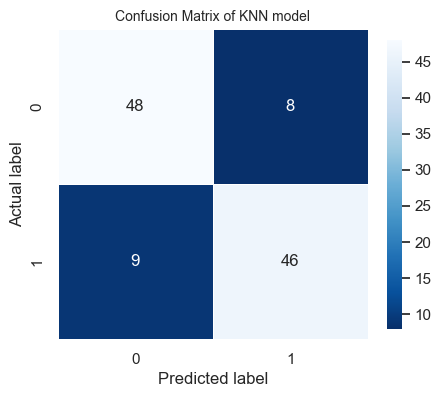

In [45]:
ytest_KNN_predict = KNN_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, ytest_KNN_predict))
print("Sensitivity for test dataset:", recall_score(y_test,ytest_KNN_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, ytest_KNN_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, ytest_KNN_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, ytest_KNN_predict))
CM_KNN = sklearn.metrics.confusion_matrix(y_test, ytest_KNN_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_KNN, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix of KNN model'
plt.title(all_sample_title, size = 10);

##### XGBOOST 

In [46]:
# train the model on train set 
XGB = xgb.XGBClassifier()
XGB.fit(X_train, y_train) 
  
# print prediction results 
XGB_pred = KNN.predict(X_test) 
print(classification_report(y_test, XGB_pred)) 

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        56
           1       0.84      0.84      0.84        55

    accuracy                           0.84       111
   macro avg       0.84      0.84      0.84       111
weighted avg       0.84      0.84      0.84       111



In [47]:
# Define the hyperparameter grid for XGBoost
param_grid= {
    'n_estimators': np.arange(10, 200, 10),  # Adjust the number of estimators as needed
    'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 1],
    'max_depth': [3, 4, 5, 6],  # Adjust the maximum depth as needed
}
xgbclassifier = xgb.XGBClassifier(random_state=11)
XGB_model = GridSearchCV(xgbclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
# Fit the model to your training data
XGB_model.fit(X_train, y_train)


Fitting 10 folds for each of 1140 candidates, totalling 11400 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=11, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007,
                                           0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.5,
                                           0.6, 0.8, 1],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [48]:
XGB_model.best_params_

{'learning_rate': 0.001, 'max_depth': 4, 'n_estimators': 10}

Accuracy for test dataset: 0.8558558558558559
Sensitivity for test dataset: 0.8545454545454545
Specificity for test dataset: 0.8571428571428571
Kappa score for test dataset: 0.7116883116883117



classification report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        56
           1       0.85      0.85      0.85        55

    accuracy                           0.86       111
   macro avg       0.86      0.86      0.86       111
weighted avg       0.86      0.86      0.86       111



Text(0.5, 1.0, 'Confusion Matrix of XGB model')

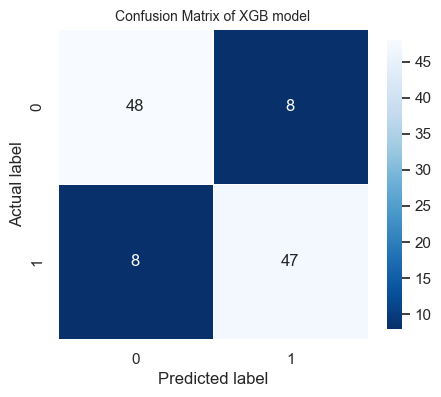

In [49]:
Y_test_XGB_predict = XGB_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, Y_test_XGB_predict))
print("Sensitivity for test dataset:", recall_score(y_test,Y_test_XGB_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, Y_test_XGB_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, Y_test_XGB_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, Y_test_XGB_predict))
CM_XGB = sklearn.metrics.confusion_matrix(y_test, Y_test_XGB_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_XGB, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Confusion Matrix of XGB model'
plt.title(title, size = 10)

### Plot the roc curve

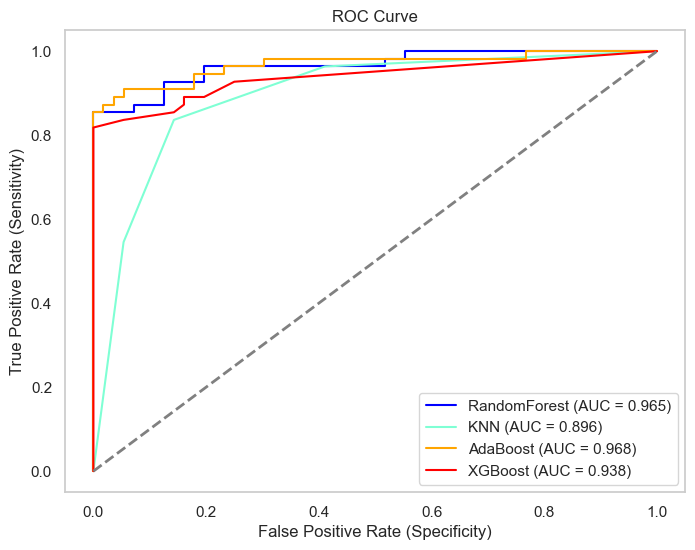

In [50]:
# plot the roc for all model 
# Predict probabilities models on the test data
y_prob_RF = RF_model.predict_proba(X_test)[:, 1]
y_prob_KNN = KNN_model.predict_proba(X_test)[:, 1]
y_prob_ADB = ADB_model.predict_proba(X_test)[:, 1]
y_prob_XGB = XGB_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve for each model
fpr_RF, tpr_RF, _ = roc_curve(y_test, y_prob_RF)
fpr_KNN, tpr_KNN, _ = roc_curve(y_test, y_prob_KNN)
fpr_ADB, tpr_ADB, _ = roc_curve(y_test, y_prob_ADB)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, y_prob_XGB)

# Calculate ROC AUC for each model
roc_auc_RF = roc_auc_score(y_test, y_prob_RF)
roc_auc_KNN = roc_auc_score(y_test, y_prob_KNN)
roc_auc_ADB = roc_auc_score(y_test, y_prob_ADB)
roc_auc_XGB = roc_auc_score(y_test, y_prob_XGB)

# Plot ROC curves for both models
plt.figure(figsize=(8, 6))
plt.plot(fpr_RF, tpr_RF, label=f'RandomForest (AUC = {roc_auc_RF:.3f})', color='blue')
plt.plot(fpr_KNN, tpr_KNN, label=f'KNN (AUC = {roc_auc_KNN:.3f})', color='aquamarine')
plt.plot(fpr_ADB, tpr_ADB, label=f'AdaBoost (AUC = {roc_auc_ADB:.3f})', color='orange')
plt.plot(fpr_XGB, tpr_XGB, label=f'XGBoost (AUC = {roc_auc_XGB:.3f})', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)
plt.xlabel('False Positive Rate (Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

#### Save model

In [51]:
models_directory = 'model_pkl/'
os.makedirs(models_directory, exist_ok=True)

In [52]:
# # # Save the best model to a file using pickle
with open(os.path.join(models_directory, 'RF_model.pkl'), 'wb') as file:
    pickle.dump(RF_model, file)

with open(os.path.join(models_directory, 'ADB_model.pkl'), 'wb') as file:
    pickle.dump(ADB_model, file)

with open(os.path.join(models_directory, 'KNN_model.pkl'), 'wb') as file:
    pickle.dump(KNN_model, file)

with open(os.path.join(models_directory, 'XGB_model.pkl'), 'wb') as file:
    pickle.dump(XGB_model, file)

#### Predicting the whole study using the machine learning models 

In [53]:
# Load each model using pickle
# Load Random Forest model
with open(os.path.join(models_directory, 'RF_model.pkl'), 'rb') as file:
    RF_model = pickle.load(file)

# Load AdaBoost model
with open(os.path.join(models_directory, 'ADB_model.pkl'), 'rb') as file:
    ADB_model = pickle.load(file)

# Load K-Nearest Neighbors (KNN) model
with open(os.path.join(models_directory, 'KNN_model.pkl'), 'rb') as file:
    KNN_model = pickle.load(file)

# Load XGBoost model
with open(os.path.join(models_directory, 'XGB_model.pkl'), 'rb') as file:
    XGB_model = pickle.load(file)


In [54]:
# Replace 'your_shapefile.shp' with the path to your shapefile
df_SA=gpd.read_file(r"D:\OCTOBER 2023\flood-suscep\flood-suscep\datasets\studyarea.shp")
# Convert the GeoPandas DataFrame to a Spark DataFrame
df_SA.head() 

,OBJECTID,pointid,grid_code,elevation,aspect,slope,plan_curva,profile_cu,drainage_d,distance_r,distance_1,landuse,rainfall,population,TWI,SPI,soil,geometry
0,1,4002254,2,2,0.000,0.000000,-0.000000,-0.111111,0.715931,60.0000,313.209,11,1422.46,573.297,0.00000,0.00000,0,POINT (467744.732 708609.411)
1,2,4002255,2,2,194.036,1.967860,-0.000000,-0.111111,0.734676,67.0820,305.941,11,1422.45,573.297,6.74341,0.00000,6,POINT (467774.732 708609.411)
2,3,4002256,2,2,225.000,1.687600,-0.194444,0.027778,0.753403,84.8528,301.496,11,1422.45,573.297,7.99108,1.72183,6,POINT (467804.732 708609.411)
3,4,4002257,3,3,288.435,0.754894,-0.000000,-0.111111,0.772129,108.1670,300.000,11,1422.45,573.297,7.65741,0.00000,6,POINT (467834.732 708609.411)
4,5,4002258,3,3,0.000,1.432100,-0.000000,0.000000,0.790855,120.0000,300.000,11,1422.45,573.297,7.05087,0.00000,6,POINT (467864.732 708609.411)


In [55]:
df_SA.shape

(4201569, 18)

In [56]:
df_SA.rename(columns={'profile_cu': 'prof_curva', 'distance_r' : 'dist_river','distance_1' : 'dist_road' }, inplace=True)
df_SA.columns

Index(['OBJECTID', 'pointid', 'grid_code', 'elevation', 'aspect', 'slope',
       'plan_curva', 'prof_curva', 'drainage_d', 'dist_river', 'dist_road',
       'landuse', 'rainfall', 'population', 'TWI', 'SPI', 'soil', 'geometry'],
      dtype='object')

In [57]:
X_SA= df_SA.drop(labels = ['OBJECTID', 'pointid', 'grid_code',
                           'geometry'], axis=1) # we need to remove all the columns except the predictive features
X_SA.head()

,elevation,aspect,slope,plan_curva,prof_curva,drainage_d,dist_river,dist_road,landuse,rainfall,population,TWI,SPI,soil
0,2,0.000,0.000000,-0.000000,-0.111111,0.715931,60.0000,313.209,11,1422.46,573.297,0.00000,0.00000,0
1,2,194.036,1.967860,-0.000000,-0.111111,0.734676,67.0820,305.941,11,1422.45,573.297,6.74341,0.00000,6
2,2,225.000,1.687600,-0.194444,0.027778,0.753403,84.8528,301.496,11,1422.45,573.297,7.99108,1.72183,6
3,3,288.435,0.754894,-0.000000,-0.111111,0.772129,108.1670,300.000,11,1422.45,573.297,7.65741,0.00000,6
4,3,0.000,1.432100,-0.000000,0.000000,0.790855,120.0000,300.000,11,1422.45,573.297,7.05087,0.00000,6


In [89]:
## Make predictions and calculate probabilities of each coordinates being flooded for each model

# prediction_prob_RF = RF_model.predict_proba(X_SA)[:, 1]
# prediction_prob_ADB = ADB_model.predict_proba(X_SA)[:, 1]
prediction_prob_KNN = KNN_model.predict_proba(X_SA)[:, 1]
prediction_prob_XGB = XGB_model.predict_proba(X_SA)[:, 1]

# Create separate GeoDataFrames for each model
# df_RF = df_SA.copy()
# df_ADB = df_SA.copy()
df_KNN = df_SA.copy()
df_XGB = df_SA.copy()

# Add the probabilities to the respective GeoDataFrames
# df_RF['FSM_RF'] = prediction_prob_RF
# df_ADB['FSM_ADB'] = prediction_prob_ADB
df_KNN['FSM_KNN'] = prediction_prob_KNN
df_XGB['FSM_XGB'] = prediction_prob_XGB


# Save each GeoDataFrame to a separate shapefile in the specified directory
# df_RF.to_file(os.path.join(models_directory, "predict_studyarea/FSM_RF.shp"))
# df_ADB.to_file(os.path.join(models_directory, "predict_studyarea/FSM_ADB.shp"))
df_KNN.to_file(os.path.join(models_directory, "predict_studyarea/FSM_KNN.shp"))
df_XGB.to_file(os.path.join(models_directory, "predict_studyarea/FSM_XGB.shp"))

# # Check the updated GeoDataFrames
# print(df_RF.head())
# print(df_ADB.head())
print(df_KNN.head())
print(df_XGB.head())

   OBJECTID  pointid  grid_code  elevation   aspect     slope  plan_curva  \
0         1  4002254          2          2    0.000  0.000000   -0.000000   
1         2  4002255          2          2  194.036  1.967860   -0.000000   
2         3  4002256          2          2  225.000  1.687600   -0.194444   
3         4  4002257          3          3  288.435  0.754894   -0.000000   
4         5  4002258          3          3    0.000  1.432100   -0.000000   

   prof_curva  drainage_d  dist_river  dist_road  landuse  rainfall  \
0   -0.111111    0.715931     60.0000    313.209       11   1422.46   
1   -0.111111    0.734676     67.0820    305.941       11   1422.45   
2    0.027778    0.753403     84.8528    301.496       11   1422.45   
3   -0.111111    0.772129    108.1670    300.000       11   1422.45   
4    0.000000    0.790855    120.0000    300.000       11   1422.45   

   population      TWI      SPI  soil                       geometry   FSM_XGB  
0     573.297  0.00000  0.000

Assessment of the relative importance of each flood conditioning factor using Spearman Analysis 

In [58]:
# Feature importances for Random Forest
feature_importance_RF = RF_model.feature_importances_

# Feature importances for AdaBoost
feature_importance_ADB = ADB_model.feature_importances_

# Feature importances for XGBoost
feature_importance_XGB = XGB_model.feature_importances_

# Dummy importance values for KNN (since KNN does not inherently provide feature importances)
feature_importance_KNN = KNN_model.feature_importances_

# Create a DataFrame to store feature names and importances
feature_importance_data = {
    'Feature': X_SA.columns,
    'RF': feature_importance_RF,
    'ADB': feature_importance_ADB,
    'XGB': feature_importance_XGB,
    'KNN': feature_importance_KNN
}

df_feature_importance = pd.DataFrame(feature_importance_data)

# Plotting stacked bar plots
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Stacked Feature Importances for Each Model')

# Stacked bar plot
df_feature_importance.set_index('Feature').plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()

AttributeError: 'GridSearchCV' object has no attribute 'feature_importances_'

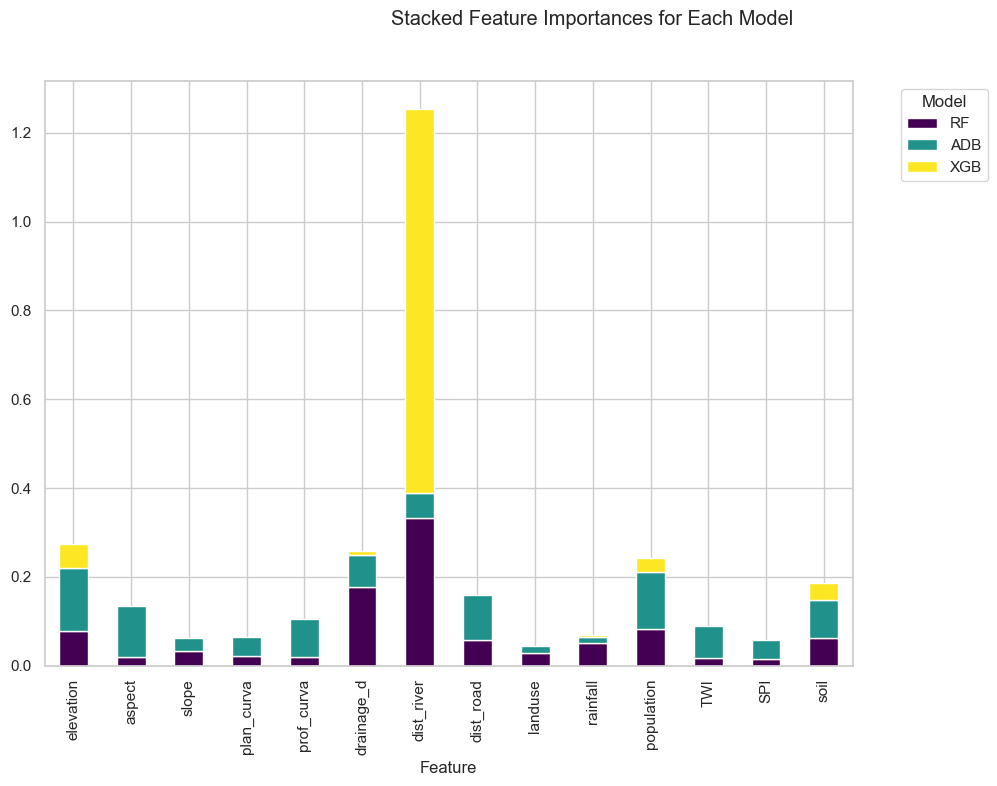

In [67]:
from sklearn.inspection import permutation_importance
# Feature importances for Random Forest
feature_importance_RF = RF_model.best_estimator_.feature_importances_

# Feature importances for AdaBoost
feature_importance_ADB = ADB_model.best_estimator_.feature_importances_


# Feature importances for XGBoost
feature_importance_XGB = XGB_model.best_estimator_.feature_importances_

# # Dummy importance values for KNN (since KNN does not inherently provide feature importances)
# feature_importance_KNN = KNN_model.best_estimator_.feature_importances_

# # Permutation importance for KNN
# perm_importance = permutation_importance(KNN_model.best_estimator_, X_SA, df_KNN['FSM_KNN'] , n_repeats=10, random_state=42)
# feature_importance_KNN = perm_importance.importances_mean

# Create a DataFrame to store feature names and importances
feature_importance_data = {
    'Feature': X_SA.columns,
    'RF': feature_importance_RF,
    'ADB': feature_importance_ADB,
    'XGB': feature_importance_XGB,
    # 'KNN': feature_importance_KNN
}

df_feature_importance = pd.DataFrame(feature_importance_data)

# Plotting stacked bar plots
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Stacked Feature Importances for Each Model')

# Stacked bar plot
df_feature_importance.set_index('Feature').plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()